# Naive Bayes Calibration — 3-Way Split (Train / Cal / Test)

**Strategy:** 3-subset split (60% train / 20% cal / 20% test).

- **Train** — Naive Bayes is fitted here.
- **Cal** — the isotonic calibrator is fitted here using `CalibratedClassifierCV(FrozenEstimator(...))` so the base model is not retrained — only the calibration mapping is learned.
- **Test** — both raw and calibrated probabilities are evaluated here. This set is never seen during fitting or calibration.

This is the cleanest approach when data allows it: each stage uses entirely different observations.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from feature_engine.encoding import OrdinalEncoder
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV
from sklearn.datasets import fetch_openml
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

SEED = 42

In [2]:
data = fetch_openml(name="bank-marketing", version=1, as_frame=True, parser="auto")
X = OrdinalEncoder(encoding_method="arbitrary").fit_transform(data.data)
y = (data.target == "2").astype(int)

# 60 / 20 / 20 split
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.40, random_state=SEED, stratify=y)
X_cal, X_test, y_cal, y_test   = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)

## Train raw model

In [3]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_cal_sc   = scaler.transform(X_cal)
X_test_sc  = scaler.transform(X_test)

gnb = GaussianNB().fit(X_train_sc, y_train)
probs_raw = gnb.predict_proba(X_test_sc)[:, 1]

## Train calibrator on cal set

`FrozenEstimator` wraps the already-fitted GNB so that `CalibratedClassifierCV` does not refit it. It only learns the isotonic mapping from cal-set scores to cal-set labels.

In [4]:
cal_gnb = CalibratedClassifierCV(FrozenEstimator(gnb), method="isotonic")
cal_gnb.fit(X_cal_sc, y_cal)
probs_cal = cal_gnb.predict_proba(X_test_sc)[:, 1]

## Performance

In [5]:
pd.DataFrame({
    "ROC-AUC":[roc_auc_score(y_test, probs_raw),
               roc_auc_score(y_test, probs_cal)],
    "Brier score": [brier_score_loss(y_test, probs_raw),
                    brier_score_loss(y_test, probs_cal)],
    "Log-loss": [log_loss(y_test, probs_raw),
                 log_loss(y_test, probs_cal)],
}, index=["Raw NB", "Calibrated NB"]).round(4)

,ROC-AUC,Brier score,Log-loss
Raw NB,0.8413,0.1197,0.6284
Calibrated NB,0.8417,0.0804,0.2708


## Calibration curves and probability histograms

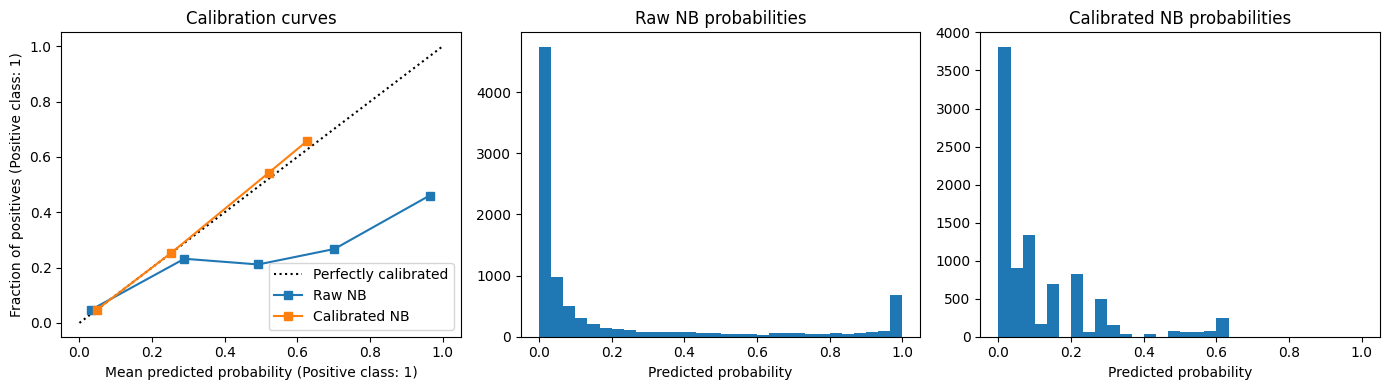

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

CalibrationDisplay.from_predictions(y_test, probs_raw, ax=axes[0], label="Raw NB")
CalibrationDisplay.from_predictions(y_test, probs_cal, ax=axes[0], label="Calibrated NB")
axes[0].set_title("Calibration curves")

axes[1].hist(probs_raw, bins=30, range=(0, 1))
axes[1].set_title("Raw NB probabilities")
axes[1].set_xlabel("Predicted probability")

axes[2].hist(probs_cal, bins=30, range=(0, 1))
axes[2].set_title("Calibrated NB probabilities")
axes[2].set_xlabel("Predicted probability")

plt.tight_layout()
outputdir="../../mlid-book/resources/ch3/ch3-nb-3way.png"
plt.savefig(outputdir, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()